# 01 · Senate return effect

This notebook checks the **CRSP return** response to congressional purchase disclosures.

**Main result:** the return effect shows up only for **Senate** purchases. House and pooled
effects disappear once we add ticker and date fixed effects.

Tables here: return ladder, Senate return windows, robustness, placebos, and the full
control coefficients. Run `00_build_panel.ipynb` first.

In [1]:
import sys
from pathlib import Path

here = Path.cwd()
ROOT = here if (here / "helpers.py").exists() else here.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from config import TABLE_DIR, FIGURE_DIR
from helpers import (BASE_CONTROLS, load_work_panel, load_quiver, trading_days,
                     purchase_events, collapse_cells, event_flag, run_panel,
                     run_event_time, coef, tidy)


In [2]:
panel = load_work_panel()
quiver = load_quiver()
days = trading_days(panel)
pidx = pd.MultiIndex.from_frame(panel[["ticker", "date"]])

# Treated ticker-day cells for each chamber.
cells = {name: collapse_cells(purchase_events(quiver, name, days)) for name in ["pooled", "house", "senate"]}
senate = cells["senate"]
print({name: len(c) for name, c in cells.items()})

{'pooled': 10542, 'house': 9136, 'senate': 1419}


## Return ladder

The `[0,+1]` return coefficient (in basis points) as we add fixed effects and controls.
Pooled and House fall to zero; **Senate stays positive and significant**.

In [3]:
specs = [("no FE", [], False, False),
         ("ticker+date FE", [], True, True),
         ("FE + controls", BASE_CONTROLS, True, True)]

rows = []
for name in ["pooled", "house", "senate"]:
    panel["flag"] = event_flag(pidx, cells[name], days, window=1)
    row = {"sample": name}
    for label, ctrl, ent, tim in specs:
        res = run_panel(panel, "crsp_ret", ["flag"], controls=ctrl, entity=ent, time=tim)
        c = coef(res, "flag")
        row[f"{label} (bps)"] = round(c["coef_bps"], 2)
        row[f"{label} p"] = round(c["p"], 3)
    rows.append(row)

ladder = pd.DataFrame(rows)
ladder.to_csv(TABLE_DIR / "return_ladder.csv", index=False)
ladder

,sample,no FE (bps),no FE p,ticker+date FE (bps),ticker+date FE p,FE + controls (bps),FE + controls p
0,pooled,23.46,0.000,2.66,0.358,3.05,0.265
1,house,20.93,0.004,-0.73,0.814,-0.16,0.956
2,senate,35.54,0.040,20.90,0.005,20.34,0.006


## Senate return windows

How long the Senate return response lasts. Each coefficient is an **average daily return**
over the treated days in the window (not a cumulative return).

In [4]:
rows = []
for w in [0, 1, 3, 5, 10]:
    panel["flag"] = event_flag(pidx, senate, days, window=w)
    res = run_panel(panel, "crsp_ret", ["flag"])
    c = coef(res, "flag")
    rows.append({"window": f"[0,+{w}]", "treated_rows": int(panel['flag'].sum()),
                 "coef_bps": round(c["coef_bps"], 2), "se_bps": round(c["se_bps"], 2),
                 "t": round(c["t"], 2), "p": round(c["p"], 4)})

senate_windows = pd.DataFrame(rows)
senate_windows.to_csv(TABLE_DIR / "senate_return_windows.csv", index=False)
senate_windows

,window,treated_rows,coef_bps,se_bps,t,p
0,"[0,+0]",1080,24.58,9.15,2.69,0.0072
1,"[0,+1]",2151,20.34,7.36,2.76,0.0057
2,"[0,+3]",4276,8.96,5.35,1.68,0.0938
3,"[0,+5]",6283,12.85,4.20,3.06,0.0022
4,"[0,+10]",11518,6.34,2.98,2.12,0.0338


## Robustness: period exclusions and stricter NBBO

Drop noisy periods (Covid Feb–Apr 2020, FOMC windows, meme-stock Jan–Jun 2021), then
raise the NBBO match-rate screen. The Senate effect survives.

In [5]:
def senate_effect(df, label):
    idx = pd.MultiIndex.from_frame(df[["ticker", "date"]])
    out = {"sample": label}
    for w in [0, 1, 5]:
        df = df.copy()
        df["flag"] = event_flag(idx, senate, days, window=w)
        c = coef(run_panel(df, "crsp_ret", ["flag"]), "flag")
        out[f"[0,+{w}] bps"] = round(c["coef_bps"], 2)
        out[f"[0,+{w}] p"] = round(c["p"], 3)
    return out

covid = panel["date"].between("2020-02-01", "2020-04-30")
meme = panel["date"].between("2021-01-01", "2021-06-30")
fomc = panel["fomc_window"].eq(1)

robust = pd.DataFrame([
    senate_effect(panel, "Main sample"),
    senate_effect(panel[~(covid | meme | fomc)], "Drop Covid/FOMC/meme"),
    senate_effect(panel[panel["nbbo_match_rate"].ge(0.75)], "NBBO >= 75%"),
    senate_effect(panel[panel["nbbo_match_rate"].ge(0.90)], "NBBO >= 90%"),
])
robust.to_csv(TABLE_DIR / "return_robustness.csv", index=False)
robust

,sample,"[0,+0] bps","[0,+0] p","[0,+1] bps","[0,+1] p","[0,+5] bps","[0,+5] p"
0,Main sample,24.58,0.007,20.34,0.006,12.85,0.002
1,Drop Covid/FOMC/meme,21.53,0.034,14.71,0.063,9.54,0.039
2,NBBO >= 75%,21.01,0.026,17.08,0.029,11.61,0.010
3,NBBO >= 90%,27.26,0.016,19.96,0.032,18.25,0.003


## Event-time figure

Return coefficient on each event day `k` from -5 to +10. The day-0 jump is clear; there is
no clean upward path afterwards.

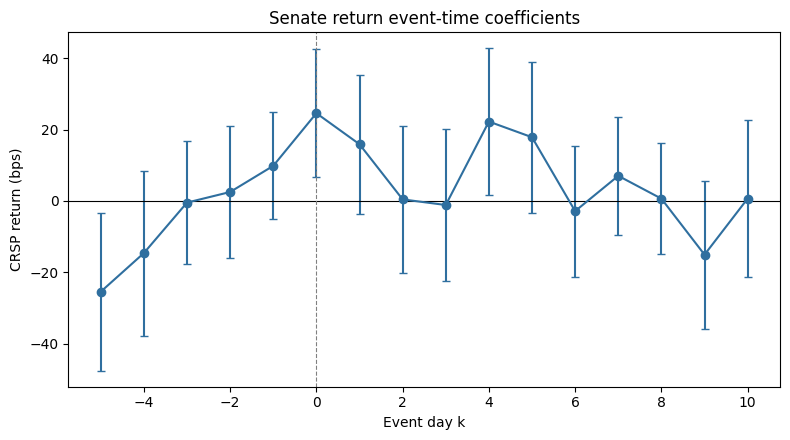

In [6]:
et = run_event_time(panel, "crsp_ret", pidx, senate, days)
et.to_csv(TABLE_DIR / "senate_return_event_time.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(et["k"], et["coef_bps"], yerr=1.96 * et["se_bps"], fmt="o-", capsize=3, color="#2f6f9f")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Event day k")
ax.set_ylabel("CRSP return (bps)")
ax.set_title("Senate return event-time coefficients")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_senate_return_event_time.png", dpi=200)
plt.show()


## Placebo: shifted disclosure dates

Move the real Senate dates to nearby non-event days. The positive return sits on the
**actual** filing day (`t+0`), not on the shifted days.

In [7]:
rows = []
for shift in [-10, -5, -3, 0, 3, 5, 10]:
    panel["flag"] = event_flag(pidx, senate, days, shift=shift)
    c = coef(run_panel(panel, "crsp_ret", ["flag"]), "flag")
    label = "t+0 (actual)" if shift == 0 else f"t{shift:+d}"
    rows.append({"shift": label, "treated_rows": int(panel['flag'].sum()),
                 "coef_bps": round(c["coef_bps"], 2), "se_bps": round(c["se_bps"], 2),
                 "p": round(c["p"], 3)})

placebos = pd.DataFrame(rows)
placebos.to_csv(TABLE_DIR / "return_placebos.csv", index=False)
placebos

,shift,treated_rows,coef_bps,se_bps,p
0,t-10,1080,8.00,10.48,0.445
1,t-5,1081,-26.48,11.18,0.018
2,t-3,1079,-0.69,8.85,0.938
3,t+0 (actual),1080,24.58,9.15,0.007
4,t+3,1081,-1.21,10.91,0.912
5,t+5,979,17.67,10.79,0.101
6,t+10,1081,-0.26,11.39,0.982


## Appendix: full control coefficients

The main `[0,+1]` Senate return regression with every control shown (returns in bps).

In [8]:
panel["flag"] = event_flag(pidx, senate, days, window=1)
res = run_panel(panel, "crsp_ret", ["flag"])
full = tidy(res)
full.to_csv(TABLE_DIR / "return_main_controls.csv")
print("Observations:", int(res.nobs), "| Within R2:", round(res.rsquared_within, 4))
full

Observations: 336433 | Within R2: 0.0063


,coef_bps,se_bps,t,p
flag,20.3387,7.3643,2.7618,0.0057
earnings_window,6.9999,4.2837,1.6341,0.1022
lag_ret_1d,4.5226,17.4474,0.2592,0.7955
lag_logdvol_1d,-22.0203,2.2977,-9.5834,0.0000
lag_amihud_5d,0.3269,0.2197,1.4879,0.1368
lag_rvol_5d,990.2190,311.7981,3.1758,0.0015
log_mktcap,57.3162,5.9706,9.5997,0.0000
